### Problem statement
- With increasing commercial electricity demand, power distribution companies need accurate demand forecasting to ensure reliable supply and efficient grid management. Variations in electricity consumption across regions depend on factors such as the number of active commercial services, connected load, and administrative location.

- The objective of this project is to build a supervised Machine Learning regression model that predicts the monthly electricity consumption (Units in kWh) for commercial areas using service-level, load, and geographical attributes.

> Accurate predictions will help TG-NPDCL to:

> Improve energy demand forecasting

> Optimize power distribution planning

> Reduce overloading and power losses

> Support data-driven infrastructure upgrades

In [1]:
import pandas as pd

In [2]:
data=pd.read_csv('TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv')

In [3]:
data.head()

,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,2,COMMERCIAL,5,5,84.0,11.000
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,2,COMMERCIAL,392,334,44762.0,872.100
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,2,COMMERCIAL,492,431,31931.0,568.730
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,2,COMMERCIAL,458,407,28871.0,657.578
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,2,COMMERCIAL,326,262,111598.0,2199.410


Circle:
Circle is the highest administrative unit in the electricity distribution system. It groups multiple divisions and is mainly used for regional planning and policy decisions. In machine learning, it helps capture large-scale variations in electricity demand.

Division:
Division operates under a circle and is responsible for operational management. It reflects differences in infrastructure and commercial activity, helping the model learn mid-level demand patterns.

SubDivision:
SubDivision is a smaller unit within a division that manages several sections. It represents localized control and helps the model understand local electricity consumption behavior.

Section:
Section handles billing, maintenance, and monitoring for a group of areas. It provides fine-grained geographical information that improves prediction accuracy.

Area:
Area is the lowest geographical unit in the dataset and represents a specific commercial zone. It plays a key role in precise area-level consumption prediction.

TotServices:
TotServices indicates the total number of registered commercial electricity connections in an area, including active and inactive services. A higher number generally leads to higher electricity consumption.

BilledServices:
BilledServices represents the number of commercial connections that were actively billed during the month. It reflects actual usage and is one of the strongest predictors of consumption.

Load:
Load represents the total connected electrical load sanctioned for commercial connections in an area. It shows the maximum power capacity available and influences consumption potential.

Units:
Units represent the total electricity consumed during January 2025, measured in kilowatt-hours. This is the target variable that the machine learning model is trained to predict.

CatCode:
CatCode is a numerical or alphanumeric code assigned to each electricity consumer category. It is mainly used for internal classification and system-level identification. In machine learning, this feature helps distinguish different consumer categories and is typically treated as a categorical variable rather than a numerical value.

CatDesc:
CatDesc is the descriptive name of the electricity consumer category corresponding to the category code. It explains the type of consumer, such as commercial, domestic, or industrial. In machine learning, this feature provides meaningful category information that helps the model understand differences in consumption behavior across consumer types.


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8335 entries, 0 to 8334
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Circle          8335 non-null   object 
 1   Division        8335 non-null   object 
 2   SubDivision     8335 non-null   object 
 3   Section         8335 non-null   object 
 4   Area            8335 non-null   object 
 5   CatCode         8335 non-null   int64  
 6   CatDesc         8335 non-null   object 
 7   TotServices     8335 non-null   int64  
 8   BilledServices  8335 non-null   int64  
 9   Units           8335 non-null   float64
 10  Load            8335 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 716.4+ KB


In [5]:
data.isna().sum()

Circle            0
Division          0
SubDivision       0
Section           0
Area              0
CatCode           0
CatDesc           0
TotServices       0
BilledServices    0
Units             0
Load              0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

Dataset Shape:
(8335, 11)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8335 entries, 0 to 8334
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Circle          8335 non-null   object 
 1   Division        8335 non-null   object 
 2   SubDivision     8335 non-null   object 
 3   Section         8335 non-null   object 
 4   Area            8335 non-null   object 
 5   CatCode         8335 non-null   int64  
 6   CatDesc         8335 non-null   object 
 7   TotServices     8335 non-null   int64  
 8   BilledServices  8335 non-null   int64  
 9   Units           8335 non-null   float64
 10  Load            8335 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 716.4+ KB
None

Statistical Summary (Numerical Features):
       CatCode  TotServices  BilledServices          Units          Load
count   8335.0  8335.000000     8335.000000    8335.000000   8335.000000
mean     

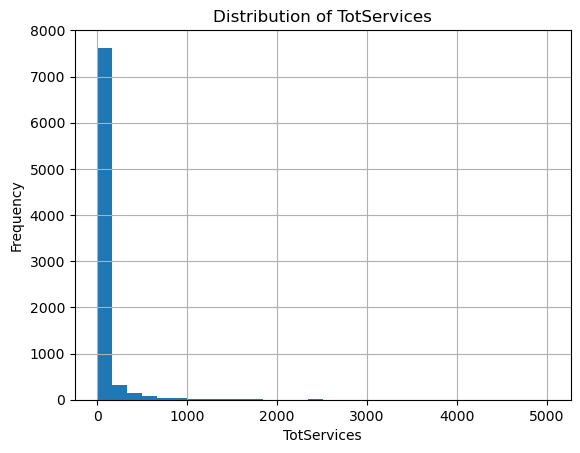

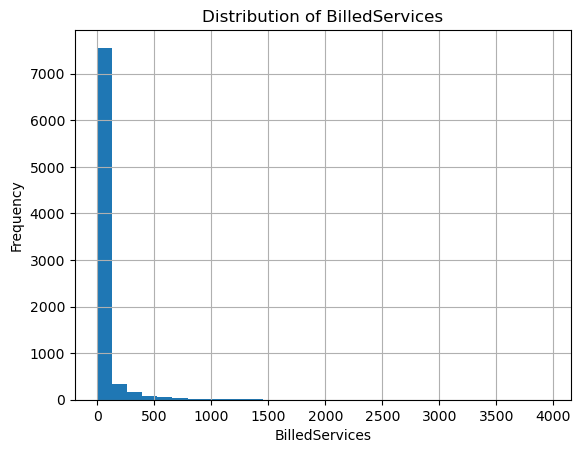

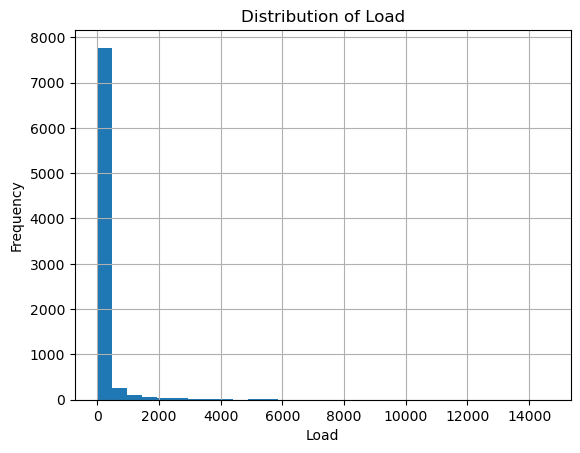

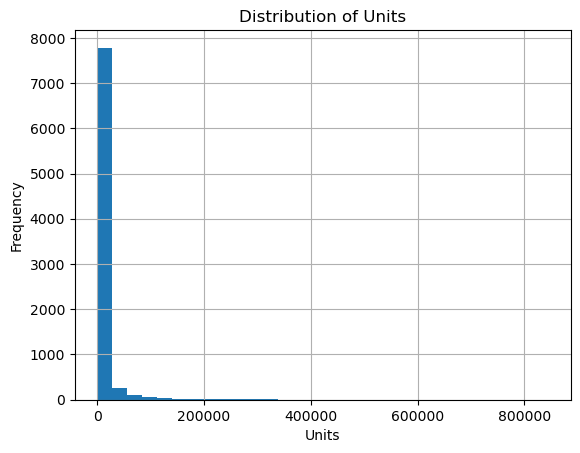


Value Counts for Circle:
Circle
BHADRADRI KOTHAGUDEM    782
KHAMMAM                 773
NIZAMABAD               610
ADILABAD                590
MAHABUBABAD             567
BHUPALAPALLY            549
KAMAREDDY               520
KARIMNAGAR              507
MANCHERIAL              500
NIRMAL                  495
Name: count, dtype: int64

Value Counts for Division:
Division
ADILABAD            386
MAHABUBABAD         362
MANCHERIAL          345
KOTHAGUDEM          327
BHUPALAPALLY        288
NIRMAL              281
JAGITYAL            277
HANAMKONDA/RURAL    271
ASIFABAD            264
BHADRACHALAM        261
Name: count, dtype: int64

Value Counts for SubDivision:
SubDivision
UTNOOR            204
KORIVI            171
ECHODA            161
ASIFABAD RURAL    132
ASIFABAD          132
MULUG             127
MANUGURU          121
BHAINSA           121
CHENNUR           115
KHANAPUR          114
Name: count, dtype: int64

Value Counts for Section:
Section
KAGAZNAGAR RURAL       64
DUMMUGUD

In [7]:
# Univariate Analysis for TG-NPDCL Dataset
# Dataset name: data

import pandas as pd
import matplotlib.pyplot as plt

# Basic info
print("Dataset Shape:")
print(data.shape)

print("\nDataset Info:")
print(data.info())

print("\nStatistical Summary (Numerical Features):")
print(data.describe())

# -----------------------------
# Univariate Analysis - Numerical Features
# -----------------------------
numerical_features = ['TotServices', 'BilledServices', 'Load', 'Units']

for col in numerical_features:
    plt.figure()
    data[col].hist(bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# -----------------------------
# Univariate Analysis - Categorical Features
# -----------------------------
categorical_features = ['Circle', 'Division', 'SubDivision', 'Section', 'Area', 'CatCode', 'CatDesc']

for col in categorical_features:
    print(f"\nValue Counts for {col}:")
    print(data[col].value_counts().head(10))


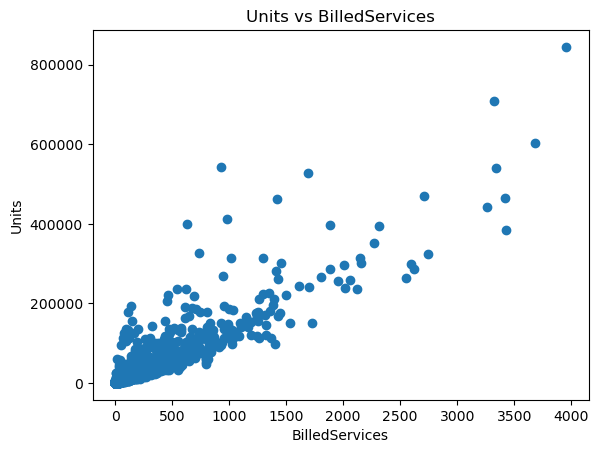

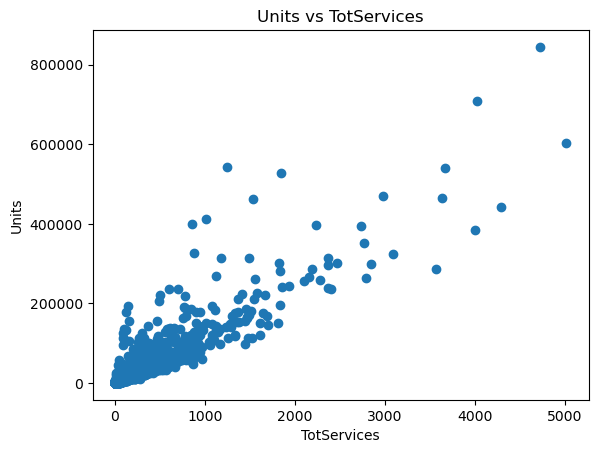

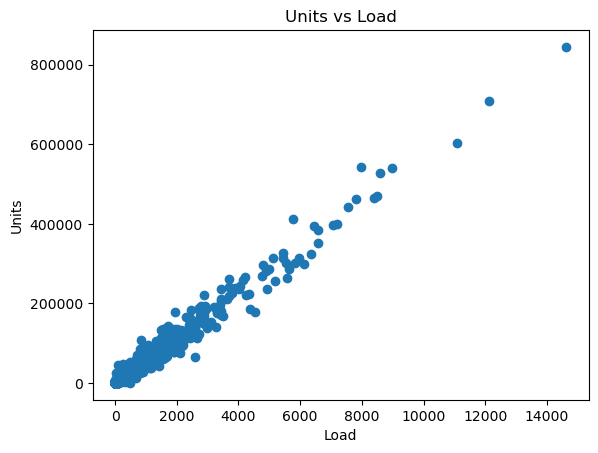

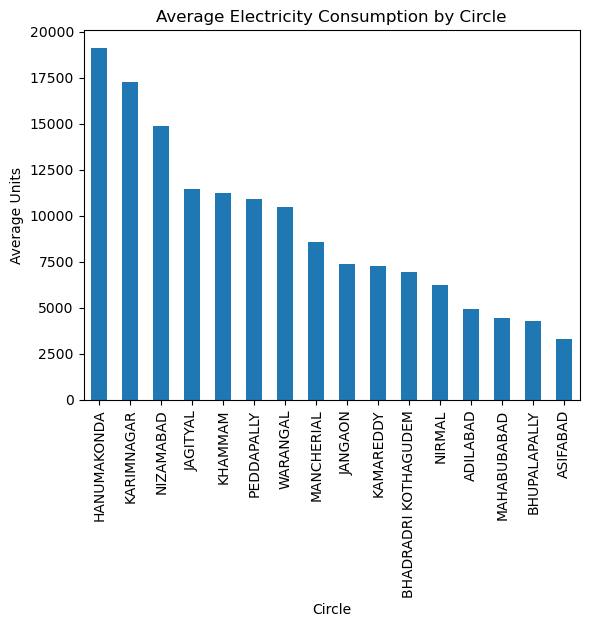

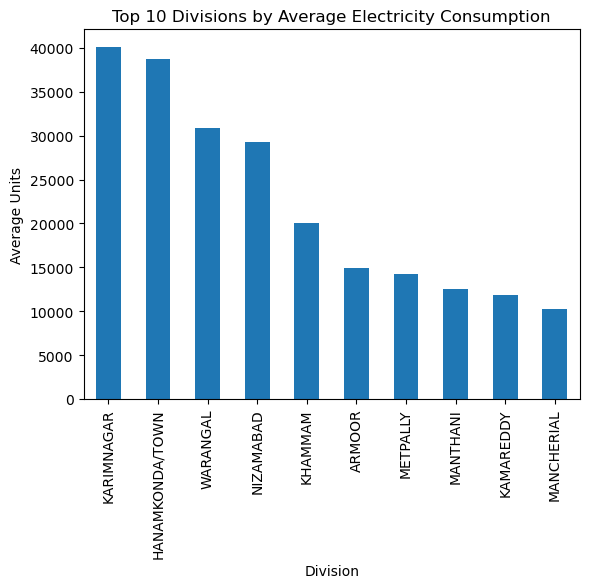

Correlation Matrix:
                TotServices  BilledServices      Load     Units
TotServices        1.000000        0.996271  0.936176  0.915527
BilledServices     0.996271        1.000000  0.933067  0.912186
Load               0.936176        0.933067  1.000000  0.988512
Units              0.915527        0.912186  0.988512  1.000000


In [8]:
# Bivariate Analysis for TG-NPDCL Dataset
# Dataset name: data

import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Numerical vs Numerical
# -----------------------------

# Units vs BilledServices
plt.figure()
plt.scatter(data['BilledServices'], data['Units'])
plt.xlabel('BilledServices')
plt.ylabel('Units')
plt.title('Units vs BilledServices')
plt.show()

# Units vs TotServices
plt.figure()
plt.scatter(data['TotServices'], data['Units'])
plt.xlabel('TotServices')
plt.ylabel('Units')
plt.title('Units vs TotServices')
plt.show()

# Units vs Load
plt.figure()
plt.scatter(data['Load'], data['Units'])
plt.xlabel('Load')
plt.ylabel('Units')
plt.title('Units vs Load')
plt.show()

# -----------------------------
# Categorical vs Numerical
# -----------------------------

# Average Units by Circle
circle_units = data.groupby('Circle')['Units'].mean().sort_values(ascending=False)

plt.figure()
circle_units.plot(kind='bar')
plt.xlabel('Circle')
plt.ylabel('Average Units')
plt.title('Average Electricity Consumption by Circle')
plt.show()

# Average Units by Division (Top 10)
division_units = data.groupby('Division')['Units'].mean().sort_values(ascending=False).head(10)

plt.figure()
division_units.plot(kind='bar')
plt.xlabel('Division')
plt.ylabel('Average Units')
plt.title('Top 10 Divisions by Average Electricity Consumption')
plt.show()

# -----------------------------
# Correlation Matrix
# -----------------------------
numerical_features = ['TotServices', 'BilledServices', 'Load', 'Units']
correlation = data[numerical_features].corr()

print("Correlation Matrix:")
print(correlation)


Correlation with Target (Units):
Units             1.000000
Load              0.988512
TotServices       0.915527
BilledServices    0.912186
Name: Units, dtype: float64


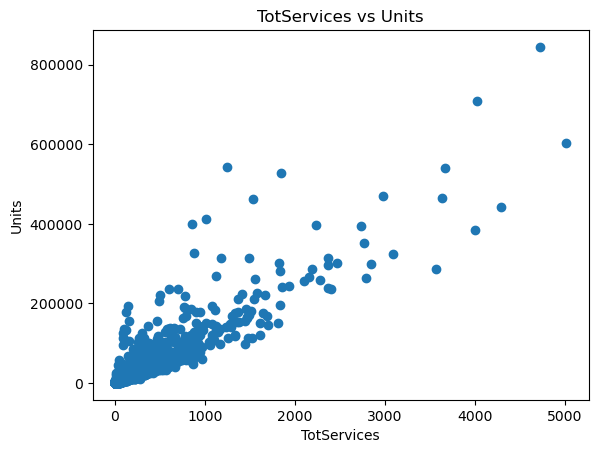

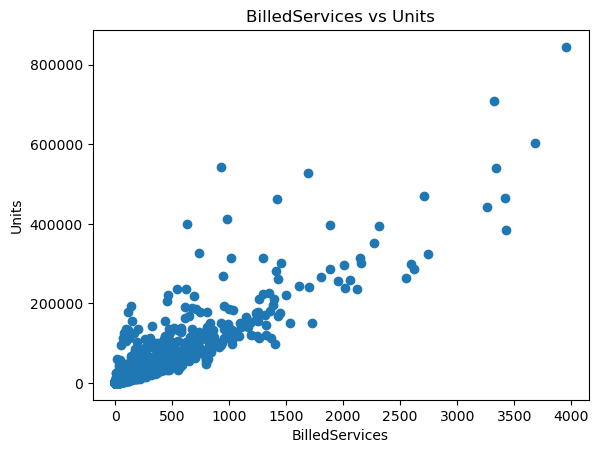

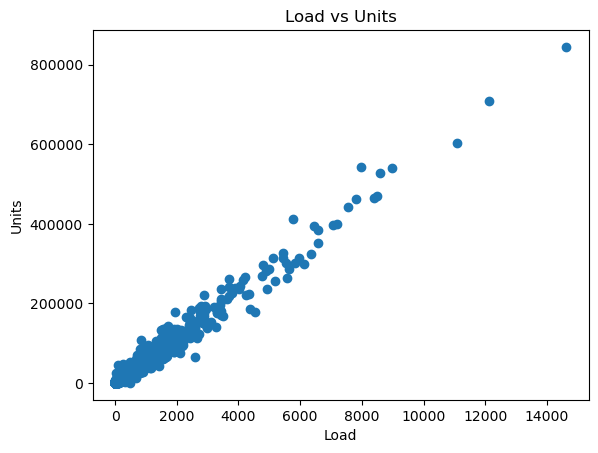


Average Units by Circle:
Circle
HANUMAKONDA    19113.669811
KARIMNAGAR     17257.652860
NIZAMABAD      14856.347541
JAGITYAL       11430.742574
KHAMMAM        11223.589909
Name: Units, dtype: float64

Average Units by Division:
Division
KARIMNAGAR         40091.500000
HANAMKONDA/TOWN    38681.450980
WARANGAL           30834.101852
NIZAMABAD          29252.888158
KHAMMAM            20077.286853
Name: Units, dtype: float64

Average Units by SubDivision:
SubDivision
KHAMMAM(T)          150453.214286
NIZAMABAD TOWN 2    108941.315789
NIZAMABAD - TOWN     84086.000000
KHAMMAM TOWN 2       83886.333333
NIZAMABAD TOWN 3     67604.500000
Name: Units, dtype: float64

Average Units by Section:
Section
BCM-TOWN            844628.0
ADILABAD - SOUTH    603811.0
JAGTIAL TOWN II     540697.0
JAGTIAL TOWN I      464957.0
PALVONCHA TOWN-2    351837.0
Name: Units, dtype: float64


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Correlation with Target
# -----------------------------
numerical_features = ['TotServices', 'BilledServices', 'Load', 'Units']

correlation = data[numerical_features].corr()

print("Correlation with Target (Units):")
print(correlation['Units'].sort_values(ascending=False))

# -----------------------------
# Scatter plots: Feature vs Target
# -----------------------------
features = ['TotServices', 'BilledServices', 'Load']

for col in features:
    plt.figure()
    plt.scatter(data[col], data['Units'])
    plt.xlabel(col)
    plt.ylabel('Units')
    plt.title(f'{col} vs Units')
    plt.show()

# -----------------------------
# Categorical Features vs Target (Mean Units)
# -----------------------------
categorical_features = ['Circle', 'Division', 'SubDivision', 'Section']

for col in categorical_features:
    print(f"\nAverage Units by {col}:")
    print(data.groupby(col)['Units'].mean().sort_values(ascending=False).head(5))


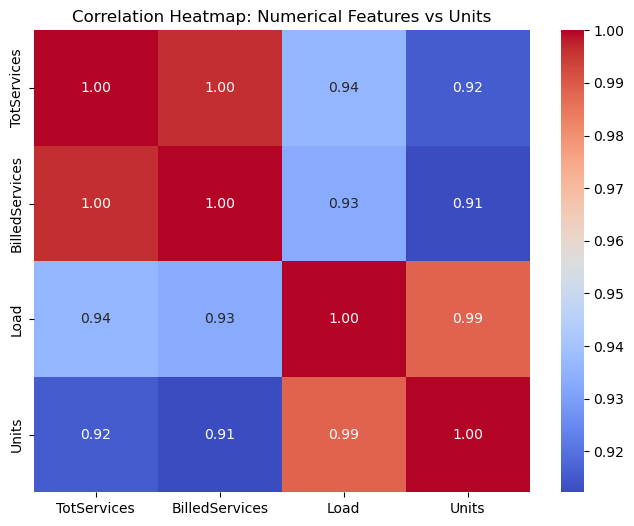

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select numerical features
numerical_features = ['TotServices', 'BilledServices', 'Load', 'Units']

# Correlation matrix
corr_matrix = data[numerical_features].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Numerical Features vs Units')
plt.show()


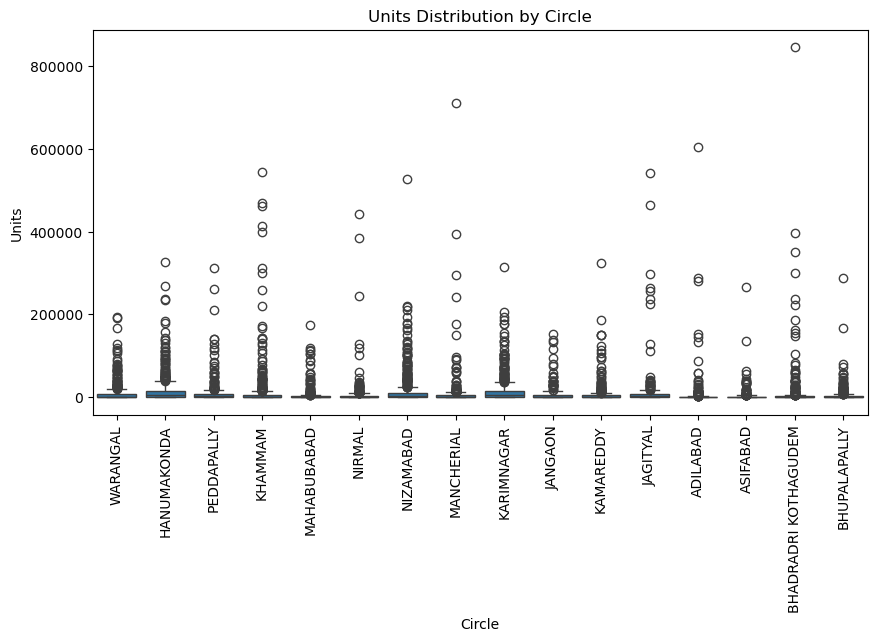

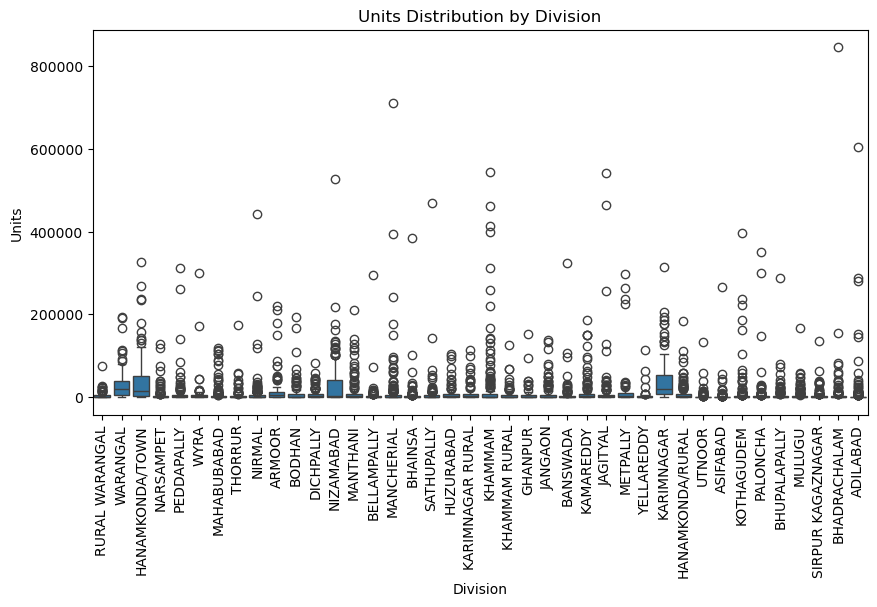

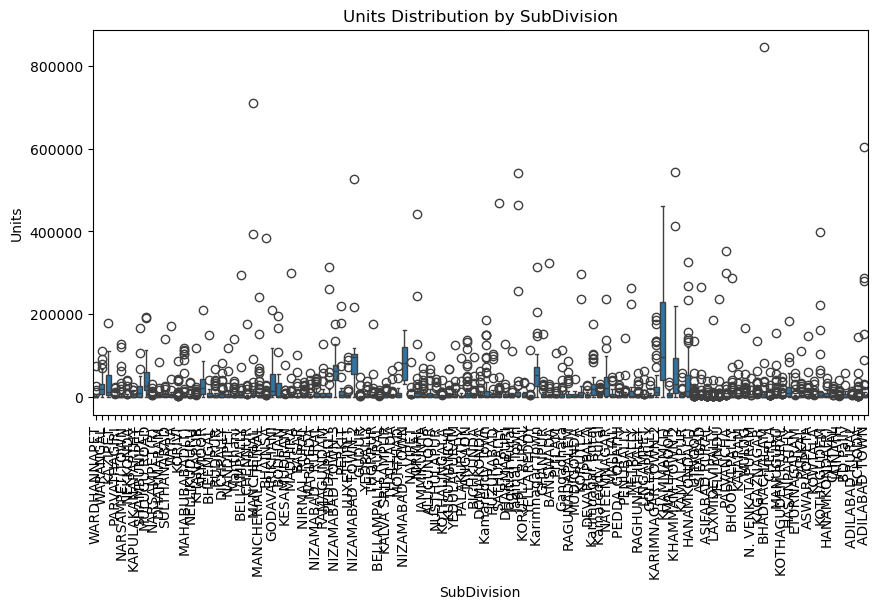

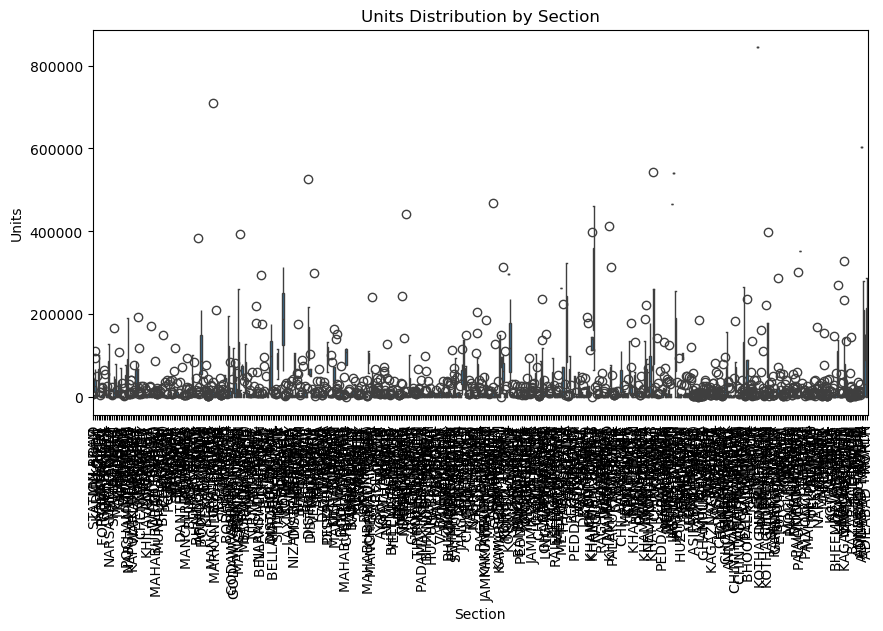

In [10]:
# Categorical features
categorical_features = ['Circle', 'Division', 'SubDivision', 'Section']

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=data[col], y=data['Units'])
    plt.xticks(rotation=90)
    plt.title(f'Units Distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Units')
    plt.show()


In [11]:
data.head()

,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,2,COMMERCIAL,5,5,84.0,11.000
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,2,COMMERCIAL,392,334,44762.0,872.100
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,2,COMMERCIAL,492,431,31931.0,568.730
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,2,COMMERCIAL,458,407,28871.0,657.578
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,2,COMMERCIAL,326,262,111598.0,2199.410


In [12]:
data.Circle.nunique()

16

In [13]:
data.Division.nunique()

40

In [14]:
data.SubDivision.nunique()

123

In [15]:
data.Area.nunique()

7224

In [16]:
data.CatCode.nunique()

1

In [17]:
data.CatDesc.nunique()

1

In [18]:
data=data.drop(['CatCode','CatDesc'],axis=1)

In [19]:
data.head()

,Circle,Division,SubDivision,Section,Area,TotServices,BilledServices,Units,Load
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,5,5,84.0,11.000
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,392,334,44762.0,872.100
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,492,431,31931.0,568.730
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,458,407,28871.0,657.578
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,326,262,111598.0,2199.410


In [20]:
X=data.drop('Units',axis=1)

In [21]:
y=data[['Units']]

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [24]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6251, 8), (2084, 8), (6251, 1), (2084, 1))

In [25]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

model = RandomForestRegressor()
model.fit(X_train, y_train)

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

print(feature_importance.sort_values(by='Importance', ascending=False))

ValueError: could not convert string to float: 'JAGITYAL'

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


KeyboardInterrupt: 

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [27]:
oe=OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

In [28]:
from sklearn.compose import ColumnTransformer

In [29]:
ct=ColumnTransformer([('p',oe,['Circle', 'Division', 'SubDivision', 'Section', 'Area'])],
                     verbose_feature_names_out=False,remainder='passthrough').set_output(transform='pandas')

In [30]:
X_train_trans=ct.fit_transform(X_train)

In [31]:
X_test_trans=ct.transform(X_test)

In [32]:
from sklearn.tree import DecisionTreeRegressor

In [33]:
dt=DecisionTreeRegressor(max_depth=10, min_samples_leaf=5)


In [34]:
dt.fit(X_train_trans,y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=5)

In [35]:
dt.score(X_train_trans,y_train)

0.9750061312592767

In [36]:
y_pre=dt.predict(X_test_trans)

In [37]:
from sklearn.metrics import r2_score

In [38]:
r2_score(y_test,y_pre)

0.959185880164333

In [39]:
data.columns

Index(['Circle', 'Division', 'SubDivision', 'Section', 'Area', 'TotServices',
       'BilledServices', 'Units', 'Load'],
      dtype='object')

In [40]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pre))


In [41]:
rmse

np.float64(5727.271580121504)

In [42]:
import optuna
from sklearn.model_selection import cross_val_score,StratifiedKFold

In [52]:
import optuna
from sklearn.model_selection import cross_val_score,StratifiedKFold
# Objective
def objective(trial):
  # Levels of Hyperparameters
  criterion = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])
  max_depth = trial.suggest_int('max_depth', 2, 30)
  min_sam_split = trial.suggest_int('min_samples_split', 2, 50)
  min_sam_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
  # Model
  dt = DecisionTreeRegressor(criterion= criterion, max_depth= max_depth, min_samples_split = min_sam_split, min_samples_leaf = min_sam_leaf)
  # Metric
  skf = StratifiedKFold(n_splits = 5, shuffle = True)
  score = cross_val_score(dt, X_train_trans, y_train, scoring = 'r2', cv = skf).mean()
  return score
study = optuna.create_study(study_name = 'DT_Study', direction = 'maximize', sampler = optuna.samplers.RandomSampler())
study.optimize(objective)

In [53]:
study = optuna.create_study(study_name = 'DT_Study', direction = 'maximize', sampler = optuna.samplers.RandomSampler())
study

[I 2026-02-11 11:55:24,412] A new study created in memory with name: DT_Study


In [54]:
study.optimize(objective)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
[W 2026-02-11 11:55:25,210] Trial 0 failed with parameters: {'criterion': 'gini', 'max_depth': 9, 'min_samples_split': 24, 'min_samples_leaf': 20} because of the following error: ValueError('\nAll the 5 fits failed.\nIt is very likely that your model is misconfigured.\nYou can try to debug the error by setting error_score=\'raise\'.\n\nBelow are more details about the failures:\n--------------------------------------------------------------------------------\n5 fits failed with the following error:\nTraceback (most recent call last):\n  File "C:\\Users\\DELL\\anaconda3\\Lib\\site-packages\\sklearn\\model_selection\\_validation.py", line 866, in _fit_and_score\n    estimator.fit(X_train, y_train, **fit_params)\n    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "C:\\Users\\DELL\\anaconda3\\

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        self._parameter_constraints,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        self.get_params(deep=F

In [58]:
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, KFold

# Objective Function
def objective(trial):
    
    # Hyperparameter search space
    criterion = trial.suggest_categorical(
        'criterion', ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
    )
    max_depth = trial.suggest_int('max_depth', 2, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 50)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)

    # Model
    dt = DecisionTreeRegressor(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    # KFold for regression
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Cross validation score
    score = cross_val_score(
        dt,
        X_train_trans,
        y_train,
        scoring='neg_root_mean_squared_error',   # You can change to neg_mean_squared_error
        cv=kf
    ).mean()

    return score


# Study
study = optuna.create_study(
    study_name='DT_Study',
    direction='maximize',
    sampler=optuna.samplers.RandomSampler()
)

study.optimize(objective, n_trials=50)


[I 2026-02-11 12:04:51,076] A new study created in memory with name: DT_Study
[I 2026-02-11 12:04:51,249] Trial 0 finished with value: -10006.983617946022 and parameters: {'criterion': 'friedman_mse', 'max_depth': 7, 'min_samples_split': 31, 'min_samples_leaf': 2}. Best is trial 0 with value: -10006.983617946022.
[I 2026-02-11 12:04:56,276] Trial 1 finished with value: -9668.133357498638 and parameters: {'criterion': 'absolute_error', 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 8}. Best is trial 1 with value: -9668.133357498638.
[I 2026-02-11 12:05:00,818] Trial 2 finished with value: -9844.97239988242 and parameters: {'criterion': 'absolute_error', 'max_depth': 27, 'min_samples_split': 23, 'min_samples_leaf': 9}. Best is trial 1 with value: -9668.133357498638.
[I 2026-02-11 12:05:01,044] Trial 3 finished with value: -10217.265779045014 and parameters: {'criterion': 'squared_error', 'max_depth': 17, 'min_samples_split': 25, 'min_samples_leaf': 16}. Best is trial 1 wit

In [59]:
study.best_params

{'criterion': 'poisson',
 'max_depth': 30,
 'min_samples_split': 12,
 'min_samples_leaf': 4}

In [60]:
study.best_value

-8413.099274106276

In [61]:
print(y_train.mean())
print(y_train.std())


Units    9453.239802
dtype: float64
Units    34901.59745
dtype: float64


In [63]:
import numpy as np
y_train_log = np.log1p(y_train)


In [64]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

# Objective Function
def objective(trial):

    # Hyperparameter Search Space
    n_estimators = trial.suggest_int("n_estimators", 100, 800)
    max_depth = trial.suggest_int("max_depth", 5, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Model
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    # KFold for Regression
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Cross Validation Score (RMSE)
    score = cross_val_score(
        rf,
        X_train_trans,
        y_train_log,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        n_jobs=-1
    ).mean()

    return score


# Create Study
study = optuna.create_study(
    study_name="RF_TG_NPDCL",
    direction="maximize",  # because we use neg RMSE
    sampler=optuna.samplers.TPESampler()
)

study.optimize(objective, n_trials=50)

# Best Results
print("Best Parameters:", study.best_params)
print("Best RMSE:", -study.best_value)


[I 2026-02-11 12:29:45,227] A new study created in memory with name: RF_TG_NPDCL
[I 2026-02-11 12:29:49,402] Trial 0 finished with value: -1.0874561201252981 and parameters: {'n_estimators': 230, 'max_depth': 8, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': None}. Best is trial 0 with value: -1.0874561201252981.
[I 2026-02-11 12:29:54,443] Trial 1 finished with value: -1.0962740107401219 and parameters: {'n_estimators': 625, 'max_depth': 9, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: -1.0874561201252981.
[I 2026-02-11 12:30:01,549] Trial 2 finished with value: -1.0909562203331693 and parameters: {'n_estimators': 254, 'max_depth': 23, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 0 with value: -1.0874561201252981.
[I 2026-02-11 12:30:06,937] Trial 3 finished with value: -1.0891335906415773 and parameters: {'n_estimators': 407, 'max_depth': 15, 'min_samples_split': 19, 'min_sa

Best Parameters: {'n_estimators': 697, 'max_depth': 23, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best RMSE: 1.0726658172879033


In [65]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)


NameError: name 'model' is not defined

In [66]:
from sklearn.ensemble import RandomForestRegressor

best_params = study.best_params

model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)


In [67]:
import numpy as np

y_train_log = np.log1p(y_train)

model.fit(X_train_trans, y_train_log)


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=23, max_features='log2', min_samples_split=20,
                      n_estimators=697, n_jobs=-1, random_state=42)

In [68]:
y_pred_log = model.predict(X_test_trans)
y_pred = np.expm1(y_pred_log)


In [69]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Final RMSE (Original Scale):", rmse)


Final RMSE (Original Scale): 8572.99799299199


In [70]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Objective Function
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        model,
        X_train_trans,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        n_jobs=-1
    ).mean()

    return score


# Create Study
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler()
)

study.optimize(objective, n_trials=50)

print("Best Parameters:", study.best_params)
print("Best CV RMSE:", -study.best_value)


# Train Final Model
final_model = XGBRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_trans, y_train)

# Predictions
y_pred = final_model.predict(X_test_trans)

# Final Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("\n===== Final Model Performance =====")
print("RMSE :", rmse)
print("MAE  :", mae)
print("MAPE :", mape * 100, "%")


[I 2026-02-11 12:47:14,515] A new study created in memory with name: no-name-58399b86-3fa3-4dc6-af4d-72b8b56aaa4f
[I 2026-02-11 12:47:18,242] Trial 0 finished with value: -12446.09609375 and parameters: {'n_estimators': 656, 'max_depth': 4, 'learning_rate': 0.11422498465924645, 'subsample': 0.9546320843763684, 'colsample_bytree': 0.6323327582858594, 'gamma': 4.329821145629176, 'min_child_weight': 4}. Best is trial 0 with value: -12446.09609375.
[I 2026-02-11 12:47:22,128] Trial 1 finished with value: -11473.90927734375 and parameters: {'n_estimators': 727, 'max_depth': 4, 'learning_rate': 0.16102440786095826, 'subsample': 0.9738028172613288, 'colsample_bytree': 0.9016550456760316, 'gamma': 0.13945949731352159, 'min_child_weight': 1}. Best is trial 1 with value: -11473.90927734375.
[I 2026-02-11 12:47:24,704] Trial 2 finished with value: -12472.5609375 and parameters: {'n_estimators': 347, 'max_depth': 12, 'learning_rate': 0.17318163247088036, 'subsample': 0.7262390191089787, 'colsample

Best Parameters: {'n_estimators': 395, 'max_depth': 6, 'learning_rate': 0.027732060563686045, 'subsample': 0.6827625997355429, 'colsample_bytree': 0.8163895607558189, 'gamma': 3.693944041889772, 'min_child_weight': 8}
Best CV RMSE: 10650.06416015625

===== Final Model Performance =====
RMSE : 8935.19871071707
MAE  : 2495.343994140625
MAPE : 1.639124962293842e+19 %


In [71]:
import numpy as np

def safe_mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape = safe_mape(y_test, y_pred)
print("Safe MAPE:", mape)


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [72]:
import numpy as np

def safe_mape(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape = safe_mape(y_test, y_pred)
print("Safe MAPE:", mape)


Safe MAPE: 1124.5326070671138


In [78]:
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import category_encoders as ce

# ==============================
# Define Feature Columns
# ==============================

target = "Units"

high_card_cols = ["Area"]  # Target Encoding
low_card_cols = ["Circle", "Division", "SubDivision"]  # OneHot

X = data[high_card_cols + low_card_cols]
y = data[target]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# Preprocessing Pipeline
# ==============================

preprocessor = ColumnTransformer(
    transformers=[
        ("target_enc", ce.TargetEncoder(), high_card_cols),
        ("onehot", OneHotEncoder(handle_unknown="ignore"), low_card_cols),
    ]
)

# ==============================
# Optuna Objective
# ==============================

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        n_jobs=-1
    ).mean()

    return score


# ==============================
# Run Optuna
# ==============================

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best Parameters:", study.best_params)
print("Best CV RMSE:", -study.best_value)


# ==============================
# Train Final Model
# ==============================

final_model = RandomForestRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", final_model)
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n===== Final Model Performance =====")
print("RMSE :", rmse)
print("MAE  :", mae)


[I 2026-02-11 13:55:13,761] A new study created in memory with name: no-name-2394f63d-4d3c-48dc-923a-0a1b53e72e8c
[I 2026-02-11 13:55:16,704] Trial 0 finished with value: -20868.39677344512 and parameters: {'n_estimators': 386, 'max_depth': 13, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: -20868.39677344512.
[I 2026-02-11 13:55:26,421] Trial 1 finished with value: -21900.586664199156 and parameters: {'n_estimators': 342, 'max_depth': 9, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 0 with value: -20868.39677344512.
[I 2026-02-11 13:55:31,476] Trial 2 finished with value: -20466.5013358731 and parameters: {'n_estimators': 565, 'max_depth': 15, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 2 with value: -20466.5013358731.
[I 2026-02-11 13:55:35,206] Trial 3 finished with value: -20797.754074136086 and parameters: {'n_estimators': 233, 'max_depth': 32, 'mi

Best Parameters: {'n_estimators': 588, 'max_depth': 32, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best CV RMSE: 19914.081030995963

===== Final Model Performance =====
RMSE : 20302.672922361173
MAE  : 9173.209454538148


In [74]:
!pip install category_encoders


In [76]:
print(y.describe())


count      8335.000000
mean       9143.704979
std       33388.240357
min           0.000000
25%         131.000000
50%        1056.000000
75%        5491.000000
max      844628.000000
Name: Units, dtype: float64


In [77]:
upper_limit = data["Units"].quantile(0.99)
data["Units"] = np.where(data["Units"] > upper_limit, upper_limit, data["Units"])


In [6]:
data = data.drop(["Area"], axis=1)

In [83]:
import numpy as np
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# =====================================================
# 1️⃣ Feature Engineering
# =====================================================

data = data.copy()

# Drop identifier columns
data = data.drop(["Area"], axis=1)

# Derived features (adjust column names if slightly different)
data["Load_per_Service"] = data["Load"] / (data["No_of_Services"] + 1e-6)
data["Billing_Ratio"] = data["Billed_Services"] / (data["No_of_Services"] + 1e-6)
data["Log_Load"] = np.log1p(data["Load"])

target = "Units"

X = data.drop(target, axis=1)
y = data[target]

# =====================================================
# 2️⃣ Train Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================================
# 3️⃣ Encoding Strategy
# =====================================================

categorical_cols = ["Circle", "Division", "SubDivision", "Section"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# =====================================================
# 4️⃣ Optuna Hyperparameter Tuning
# =====================================================

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 700),
        "max_depth": trial.suggest_int("max_depth", 10, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 5, 25),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": "sqrt",
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        n_jobs=-1
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best Parameters:", study.best_params)
print("Best CV RMSE:", -study.best_value)

# =====================================================
# 5️⃣ Final Model Training
# =====================================================

final_model = RandomForestRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", final_model)
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n===== Final Model Performance =====")
print("RMSE :", rmse)
print("MAE  :", mae)


KeyError: 'No_of_Services'

In [84]:
print(data.columns)


Index(['Circle', 'Division', 'SubDivision', 'Section', 'TotServices',
       'BilledServices', 'Units', 'Load'],
      dtype='object')


In [85]:
import numpy as np
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# ===============================
# 1️⃣ Feature Engineering
# ===============================

data = data.copy()

data["Load_per_Service"] = data["Load"] / (data["TotServices"] + 1e-6)
data["Billing_Ratio"] = data["BilledServices"] / (data["TotServices"] + 1e-6)
data["Log_Load"] = np.log1p(data["Load"])

target = "Units"

X = data.drop(target, axis=1)
y = data[target]

# ===============================
# 2️⃣ Train Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 3️⃣ Encoding Strategy
# ===============================

categorical_cols = ["Circle", "Division", "SubDivision", "Section"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# ===============================
# 4️⃣ Optuna Hyperparameter Tuning
# ===============================

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 700),
        "max_depth": trial.suggest_int("max_depth", 10, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 5, 25),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": "sqrt",
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        n_jobs=-1
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best Parameters:", study.best_params)
print("Best CV RMSE:", -study.best_value)

# ===============================
# 5️⃣ Final Model
# ===============================

final_model = RandomForestRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", final_model)
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n===== Final Model Performance =====")
print("RMSE :", rmse)
print("MAE  :", mae)


[I 2026-02-11 15:12:20,730] A new study created in memory with name: no-name-6d7c8994-3cab-42ed-b5e6-4b9e9a852cd9
[I 2026-02-11 15:12:30,633] Trial 0 finished with value: -16023.849484495146 and parameters: {'n_estimators': 699, 'max_depth': 13, 'min_samples_split': 13, 'min_samples_leaf': 5}. Best is trial 0 with value: -16023.849484495146.
[I 2026-02-11 15:12:41,052] Trial 1 finished with value: -14658.93377613888 and parameters: {'n_estimators': 663, 'max_depth': 28, 'min_samples_split': 12, 'min_samples_leaf': 5}. Best is trial 1 with value: -14658.93377613888.
[I 2026-02-11 15:12:45,699] Trial 2 finished with value: -12815.747073328097 and parameters: {'n_estimators': 548, 'max_depth': 18, 'min_samples_split': 23, 'min_samples_leaf': 1}. Best is trial 2 with value: -12815.747073328097.
[I 2026-02-11 15:12:51,647] Trial 3 finished with value: -13766.895851740826 and parameters: {'n_estimators': 632, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 2 wi

Best Parameters: {'n_estimators': 334, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 1}
Best CV RMSE: 11464.241996236724

===== Final Model Performance =====
RMSE : 4696.985071651713
MAE  : 1766.6474623535332


In [8]:
data.to_csv("cleaned_data.csv", index=False)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
import pandas as pd

# Create model
model = LinearRegression()

# Select number of features you want
rfe = RFE(estimator=model, n_features_to_select=5)

# Fit RFE
rfe.fit(X_train, y_train)

# Selected features
selected_features = X_train.columns[rfe.support_]

print("Selected Features:")
print(selected_features)
categorical_cols = ["Circle", "Division", "SubDivision", "Section"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [ ]:
categorical_cols = ["Circle", "Division", "SubDivision", "Section"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [25]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [27]:
X_train.columns

Index(['Circle', 'Division', 'SubDivision', 'Section', 'Area', 'TotServices',
       'BilledServices', 'Load'],
      dtype='object')

In [28]:
categorical_cols = ["Circle", "Division", "SubDivision", "Section", "Area"]

numerical_cols = ["TotServices", "BilledServices", "Load"]

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [30]:
encoded_cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)

feature_names = list(encoded_cat_features) + numerical_cols

AttributeError: 'ColumnTransformer' object has no attribute 'transformers_'

In [31]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [32]:
preprocessor.transformers_

[('cat',
  OneHotEncoder(handle_unknown='ignore'),
  ['Circle', 'Division', 'SubDivision', 'Section', 'Area']),
 ('num',
  FunctionTransformer(accept_sparse=True, check_inverse=False,
                      feature_names_out='one-to-one'),
  ['TotServices', 'BilledServices', 'Load'])]

In [33]:
encoded_cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)

feature_names = list(encoded_cat_features) + numerical_cols

In [34]:
print(feature_names[:10])

['Circle_ADILABAD', 'Circle_ASIFABAD', 'Circle_BHADRADRI KOTHAGUDEM', 'Circle_BHUPALAPALLY', 'Circle_HANUMAKONDA', 'Circle_JAGITYAL', 'Circle_JANGAON', 'Circle_KAMAREDDY', 'Circle_KARIMNAGAR', 'Circle_KHAMMAM']


In [35]:
X_train_processed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 49888 stored elements and shape (6251, 6187)>

In [37]:
X_train

,Circle,Division,SubDivision,Section,Area,TotServices,BilledServices,Load
3317,JAGITYAL,JAGITYAL,DHARMAPURI,RAJARAMPALLY,KONDAPOOR,29,27,38.048
7884,BHADRADRI KOTHAGUDEM,KOTHAGUDEM,KOTHAGUDEM RURAL,CHANDRUGONDA,TEKULA BANZAR-CG,6,6,12.000
6675,BHUPALAPALLY,BHUPALAPALLY,CHITYAL,MOGULLAPALLY,YELLAREDDYPALLY,13,12,22.150
904,KHAMMAM,WYRA,WYRA,BONAKAL,CHIRUNOMULA,81,74,178.295
7948,ADILABAD,UTNOOR,UTNOOR,NARNOOR,ARJUNI,1,1,1.000
...,...,...,...,...,...,...,...,...
5734,ASIFABAD,SIRPUR KAGAZNAGAR,KAGAZNAGAR,KAGAZNAGAR RURAL,PANCHSHELNAGAR,10,9,41.020
5191,JAGITYAL,JAGITYAL,Jagitial Town,POLASA,GUTTARAJPALLY,15,14,33.805
5390,KHAMMAM,KHAMMAM RURAL,YEDULAPURAM,YEDULAPURAM,JALAGAM NAGAR,90,86,172.880
860,NIZAMABAD,NIZAMABAD,NANDIPET,GOTTIMUKLA,KOTHAPALLY,52,51,82.863


In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [39]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [40]:
encoded_cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)

feature_names = list(encoded_cat_features) + numerical_cols

In [41]:
model = LinearRegression()

model.fit(X_train_processed, y_train)

LinearRegression()

In [42]:
importance = np.abs(model.coef_)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

ValueError: Per-column arrays must each be 1-dimensional

In [43]:
importance = np.abs(model.coef_)

In [44]:
importance = np.abs(model.coef_).flatten()

In [111]:
importance = np.abs(model.coef_).flatten()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

               Feature   Importance
8    Circle_KARIMNAGAR  1316.932193
4   Circle_HANUMAKONDA  1079.564979
14   Circle_PEDDAPALLY  1024.295692
6       Circle_JANGAON   906.379313
7     Circle_KAMAREDDY   562.191581
13    Circle_NIZAMABAD   454.341118
1      Circle_ASIFABAD   376.513149
11   Circle_MANCHERIAL   362.547718
10  Circle_MAHABUBABAD   322.275472
12       Circle_NIRMAL   136.797823


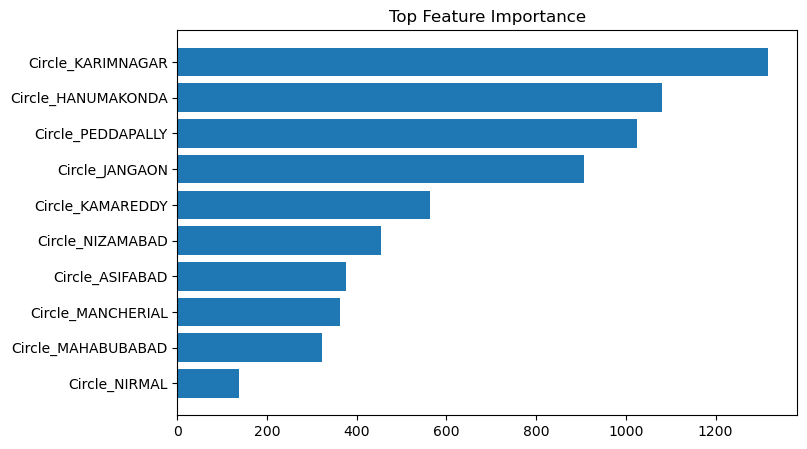

In [112]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importance")
plt.show()

In [113]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Create model
model = LinearRegression()

# Select number of features
rfe = RFE(estimator=model, n_features_to_select=10)

# Fit RFE
rfe.fit(X_train_processed, y_train)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\feature_selection\_rfe.py:300: UserWarning: Found n_features_to_select=10 > n_features=3. There will be no feature selection and all features will be kept.
  warnings.warn(


RFE(estimator=LinearRegression(), n_features_to_select=10)

In [48]:
X.columns

Index(['Circle', 'Division', 'SubDivision', 'Section', 'Area', 'TotServices',
       'BilledServices', 'Load'],
      dtype='object')

In [102]:
features = [
            'TotServices', 'BilledServices', 'Load']

X = data[features]

y = data['Units']

In [103]:
X.head()

,TotServices,BilledServices,Load
0,5,5,11.000
1,392,334,872.100
2,492,431,568.730
3,458,407,657.578
4,326,262,2199.410


In [104]:


numerical_cols = ['TotServices', 'BilledServices', 'Load']

In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        
        ("num", "passthrough", numerical_cols)
    ]
)

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [107]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [108]:
encoded_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)

feature_names = list(encoded_features) + numerical_cols

KeyError: 'cat'

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_processed, y_train)

In [ ]:
import numpy as np
import pandas as pd

importance = np.abs(model.coef_).flatten()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

In [75]:
X.columns

Index(['Circle', 'Division', 'SubDivision', 'TotServices', 'BilledServices',
       'Load'],
      dtype='object')

In [62]:
X.Circle.nunique()

16

In [63]:
X.Division.nunique()

40

In [64]:
X.SubDivision.nunique()

123

In [65]:
X.Section.nunique()

454

In [110]:
categorical_cols = ['Circle','Division','SubDivision','Section','Area']

df_numeric = data.drop(columns=categorical_cols)

In [5]:
X = data[['TotServices','BilledServices','Load']]

y = data['Units']

In [9]:
X.head()

,TotServices,BilledServices,Load
0,5,5,11.000
1,392,334,872.100
2,492,431,568.730
3,458,407,657.578
4,326,262,2199.410


In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
X_train_trans=scaler.fit_transform(X_train)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_trans, y_train)

LinearRegression()

In [17]:
X_test_trans=scaler.transform(X_test)

In [117]:
import numpy as np
import pandas as pd

importance = np.abs(model.coef_)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

          Feature  Importance
2            Load   60.314857
0     TotServices    5.562175
1  BilledServices    5.081296


In [118]:
from sklearn.feature_selection import RFE

rfe = RFE(model, n_features_to_select=3)

rfe.fit(X_train, y_train)

selected_features = X.columns[rfe.support_]

print("Selected Features:", selected_features)

Selected Features: Index(['TotServices', 'BilledServices', 'Load'], dtype='object')


In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

pred = model.predict(X_test_trans)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score: 0.9753437835412258
MAE: 1903.3459559190317
RMSE: 4697.28528197931


In [120]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    "alpha":[0.01,0.1,1,10,50,100]
}

grid_ridge = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='r2'
)

grid_ridge.fit(X_train, y_train)

print("Best Parameters:", grid_ridge.best_params_)
print("Best Score:", grid_ridge.best_score_)

Best Parameters: {'alpha': 100}
Best Score: 0.9754214620061585


In [121]:
from sklearn.linear_model import Lasso

lasso = Lasso()

param_grid = {
    "alpha":[0.001,0.01,0.1,1,10]
}

grid_lasso = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring='r2'
)

grid_lasso.fit(X_train, y_train)

print("Best Parameters:", grid_lasso.best_params_)
print("Best Score:", grid_lasso.best_score_)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.748e+10, tolerance: 6.857e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.146e+10, tolerance: 6.832e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.157e+10, tolerance: 

Best Parameters: {'alpha': 10}
Best Score: 0.9754231324297222


In [122]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet()

param_grid = {
    "alpha":[0.01,0.1,1,10],
    "l1_ratio":[0.2,0.5,0.7,0.9]
}

grid_elastic = GridSearchCV(
    elastic,
    param_grid,
    cv=5,
    scoring='r2'
)

grid_elastic.fit(X_train, y_train)

print("Best Parameters:", grid_elastic.best_params_)
print("Best Score:", grid_elastic.best_score_)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.732e+10, tolerance: 6.857e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.140e+10, tolerance: 6.832e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.151e+10, tolerance: 

Best Parameters: {'alpha': 10, 'l1_ratio': 0.2}
Best Score: 0.9754330782314531


In [123]:
best_model = grid_ridge.best_estimator_

pred = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test,pred))
print("MAE:", mean_absolute_error(y_test,pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))

R2 Score: 0.9753437757801711
MAE: 1903.3458790270774
RMSE: 4697.286021263161


In [125]:
best_model

Ridge(alpha=100)